<a href="https://colab.research.google.com/github/kolijayesh370-ops/Offline-classes-vs-Online-classes/blob/main/Visualizations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Upload 'cleaned_survey_data.csv':


Saving cleaned_survey_data (1).csv to cleaned_survey_data (1).csv


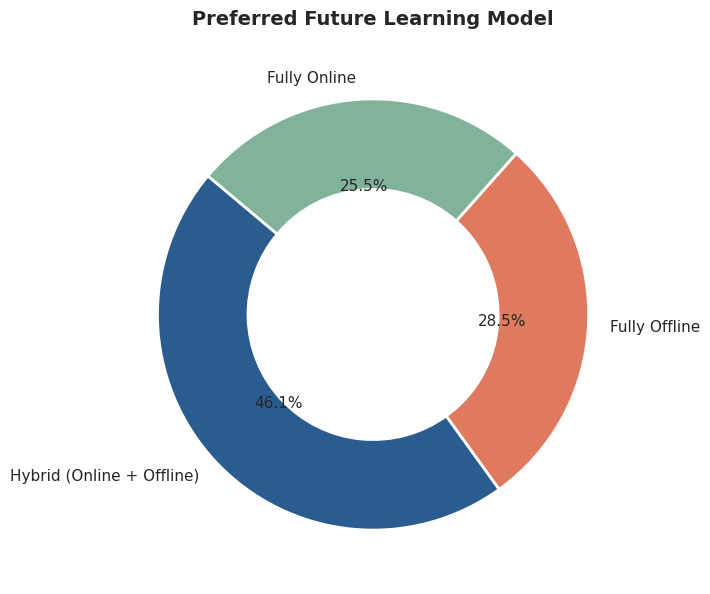

/tmp/ipykernel_495/4271474482.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=concept_counts.index, y=concept_counts.values, palette='Blues_r')


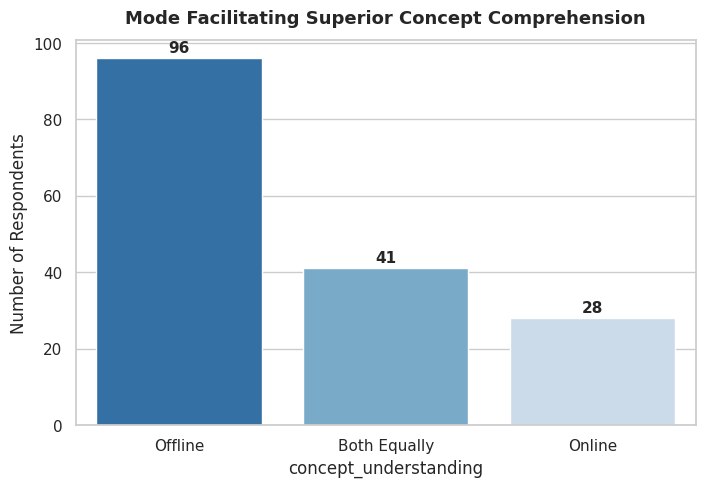

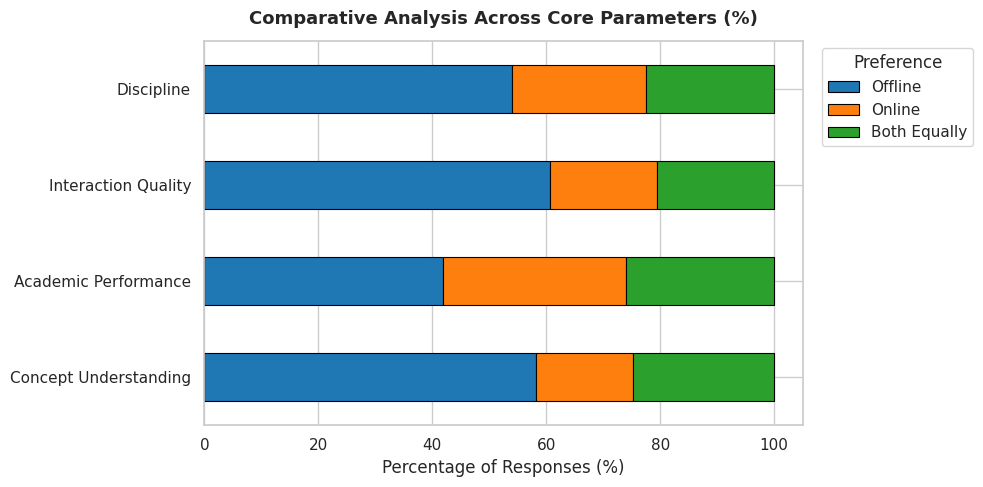

/tmp/ipykernel_495/4271474482.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=df['challenge_online'].value_counts().index,
/tmp/ipykernel_495/4271474482.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=df['challenge_offline'].value_counts().index,


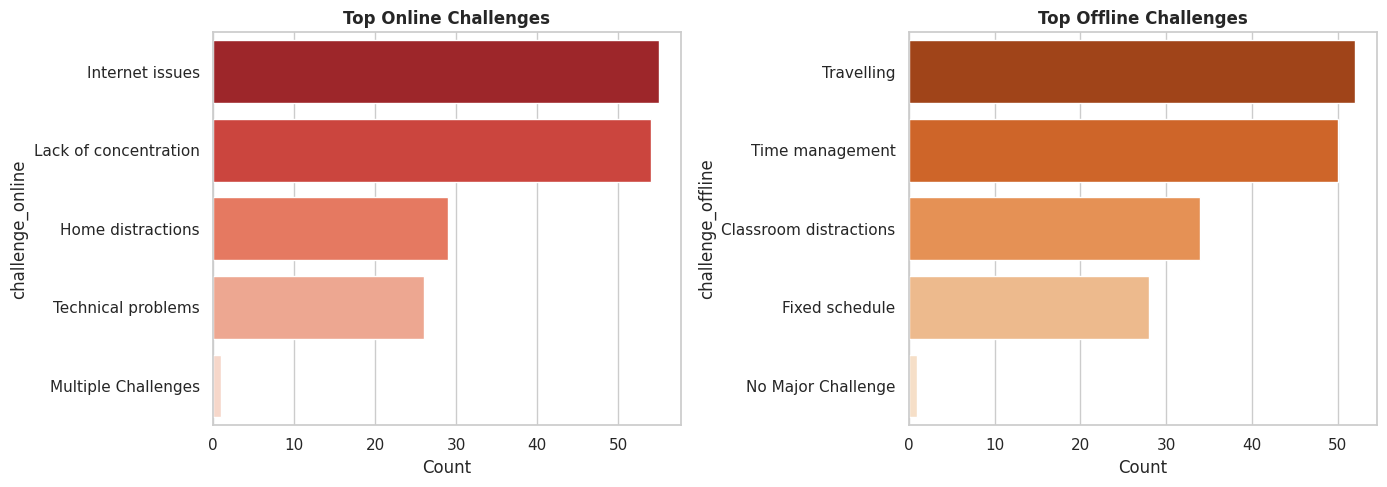

  adding: outputs/ (stored 0%)
  adding: outputs/comparative_stacked_metrics.png (deflated 25%)
  adding: outputs/concept_understanding_bar.png (deflated 23%)
  adding: outputs/challenges_breakdown.png (deflated 29%)
  adding: outputs/future_preference_donut.png (deflated 15%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
# ==========================================
# REPORT GRAPHS & CHARTS
# ==========================================
import os
import io
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

os.makedirs("outputs", exist_ok=True)
sns.set_theme(style="whitegrid")
plt.rcParams['font.size'] = 11


print("Upload 'cleaned_survey_data.csv':")
uploaded = files.upload()
csv_name = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[csv_name]))

plt.figure(figsize=(7, 7))
future_counts = df['future_preference'].value_counts()
plt.pie(future_counts, labels=future_counts.index, autopct='%1.1f%%', startangle=140,
        colors=['#2b5c8f', '#e07a5f', '#81b29a'],
        wedgeprops=dict(width=0.42, edgecolor='white', linewidth=2))
plt.title('Preferred Future Learning Model', fontsize=14, fontweight='bold', pad=15)
plt.savefig("outputs/future_preference_donut.png", dpi=300, bbox_inches='tight')
plt.show()


plt.figure(figsize=(8, 5))
concept_counts = df['concept_understanding'].value_counts()
ax = sns.barplot(x=concept_counts.index, y=concept_counts.values, palette='Blues_r')
plt.title('Mode Facilitating Superior Concept Comprehension', fontsize=13, fontweight='bold', pad=12)
plt.ylabel('Number of Respondents')
for i, v in enumerate(concept_counts.values):
    ax.text(i, v + 1.5, str(v), ha='center', fontweight='bold')
plt.savefig("outputs/concept_understanding_bar.png", dpi=300, bbox_inches='tight')
plt.show()


dimensions = {
    'Concept Understanding': df['concept_understanding'].value_counts(normalize=True) * 100,
    'Academic Performance': df['academic_performance'].value_counts(normalize=True) * 100,
    'Interaction Quality': df['teacher_student_interaction'].value_counts(normalize=True) * 100,
    'Discipline': df['discipline_mode'].value_counts(normalize=True) * 100
}
comp_df = pd.DataFrame(dimensions).T[['Offline', 'Online', 'Both Equally']]
comp_df.plot(kind='barh', stacked=True, figsize=(10, 5),
             color=['#1f77b4', '#ff7f0e', '#2ca02c'], edgecolor='black', linewidth=0.8)
plt.title('Comparative Analysis Across Core Parameters (%)', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Percentage of Responses (%)')
plt.legend(title='Preference', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig("outputs/comparative_stacked_metrics.png", dpi=300, bbox_inches='tight')
plt.show()


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(y=df['challenge_online'].value_counts().index,
            x=df['challenge_online'].value_counts().values,
            ax=axes[0], palette='Reds_r')
axes[0].set_title('Top Online Challenges', fontweight='bold')
axes[0].set_xlabel('Count')

sns.barplot(y=df['challenge_offline'].value_counts().index,
            x=df['challenge_offline'].value_counts().values,
            ax=axes[1], palette='Oranges_r')
axes[1].set_title('Top Offline Challenges', fontweight='bold')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.savefig("outputs/challenges_breakdown.png", dpi=300, bbox_inches='tight')
plt.show()

!zip -r chart_outputs.zip outputs/
files.download("chart_outputs.zip")